# Chapter 2: Important Distributions


In this notebook, we explore several important probability distributions
that frequently appear in statistics and data science.


## Randomness and Variability

In [2]:
# Simulate rolling a die 100 times

set.seed(42)

dice_rolls <- sample(1:6, size = 100, replace = TRUE)

dice_rolls[1:20]

[1] 1 5 1 1 2 4 2 2 1 4 1 5 6 4 2 2 3 1 1 3

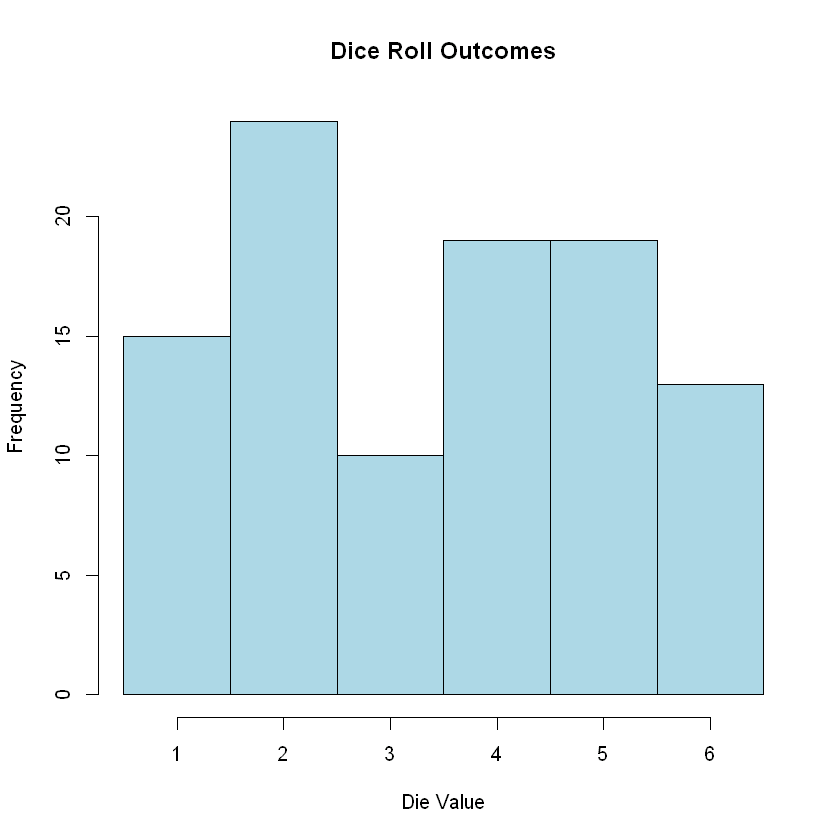

In [3]:
# Visualize the results

hist(
  dice_rolls,
  breaks = seq(0.5, 6.5, by = 1),
  main = "Dice Roll Outcomes",
  xlab = "Die Value",
  ylab = "Frequency",
  col = "lightblue"
)

## The Normal Distribution

In [4]:
# Generate data from a normal distribution

set.seed(42)

data <- rnorm(n = 1000, mean = 70, sd = 10)

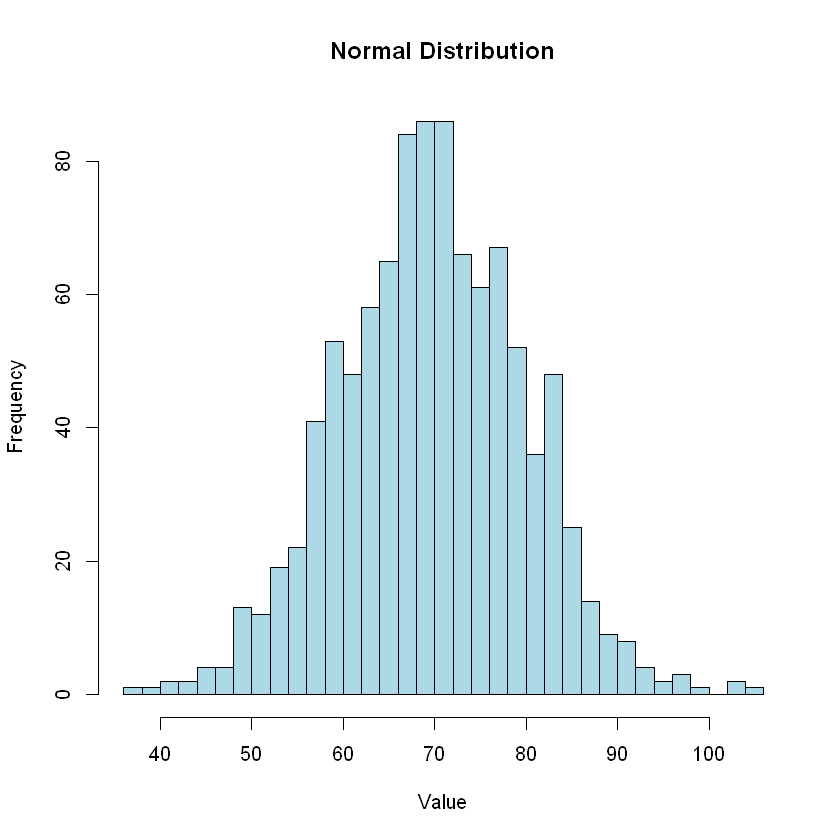

In [5]:
# Visualize the distribution

hist(
  data,
  breaks = 30,
  main = "Normal Distribution",
  xlab = "Value",
  ylab = "Frequency",
  col = "lightblue"
)

In [6]:
# Mean and standard deviation

cat("Mean:", round(mean(data), 2), "\n")
cat("Standard deviation:", round(sd(data), 2), "\n")

Mean: 69.74 
Standard deviation: 10.03 


## The Empirical Rule

In [7]:
# Percentage within one standard deviation

data_mean <- mean(data)
data_sd <- sd(data)

within_one_sd <- data[
  data >= data_mean - data_sd &
  data <= data_mean + data_sd
]

percentage <- length(within_one_sd) / length(data) * 100

cat("Percentage within one standard deviation:\n")
cat(round(percentage, 2), "%\n")

Percentage within one standard deviation:
67.5 %


## Z-Scores

In [8]:
# Exam score example

score <- 85
data_mean <- 70
data_sd <- 10

z_score <- (score - data_mean) / data_sd

cat("Z-score:", z_score, "\n")

Z-score: 1.5 


## The Binomial Distribution

In [9]:
# Probability of exactly 5 heads
# in 10 coin flips

probability <- dbinom(5, size = 10, prob = 0.5)

print(probability)

[1] 0.2460938


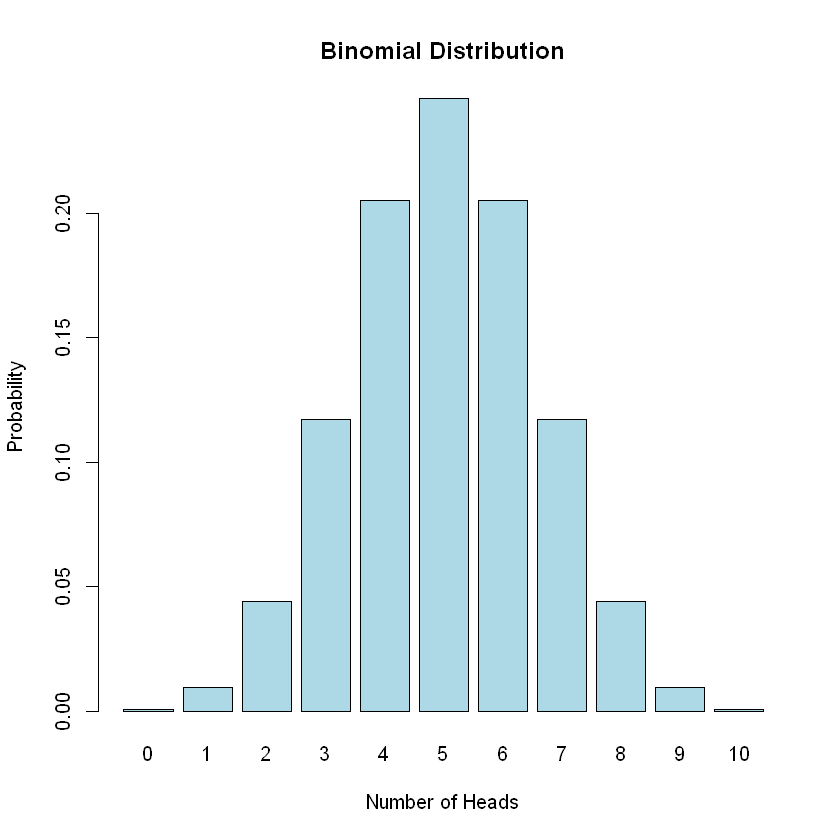

In [10]:
# Possible number of heads in 10 coin flips

x <- 0:10

# dbinom calculates the probability of each outcome
# for a binomial distribution

y <- dbinom(x, size = 10, prob = 0.5)

barplot(
  y,
  names.arg = x,
  main = "Binomial Distribution",
  xlab = "Number of Heads",
  ylab = "Probability",
  col = "lightblue"
)

In [11]:
# Mean and standard deviation
# of a binomial distribution

n <- 10
p <- 0.5

binom_mean <- n * p
binom_sd <- sqrt(n * p * (1 - p))

cat("Mean:", binom_mean, "\n")
cat("Standard deviation:", round(binom_sd, 2), "\n")

Mean: 5 
Standard deviation: 1.58 


# Appendix A: Other Important Distributions

## Poisson Distribution

In [12]:
# In R, Poisson probabilities are calculated with dpois().

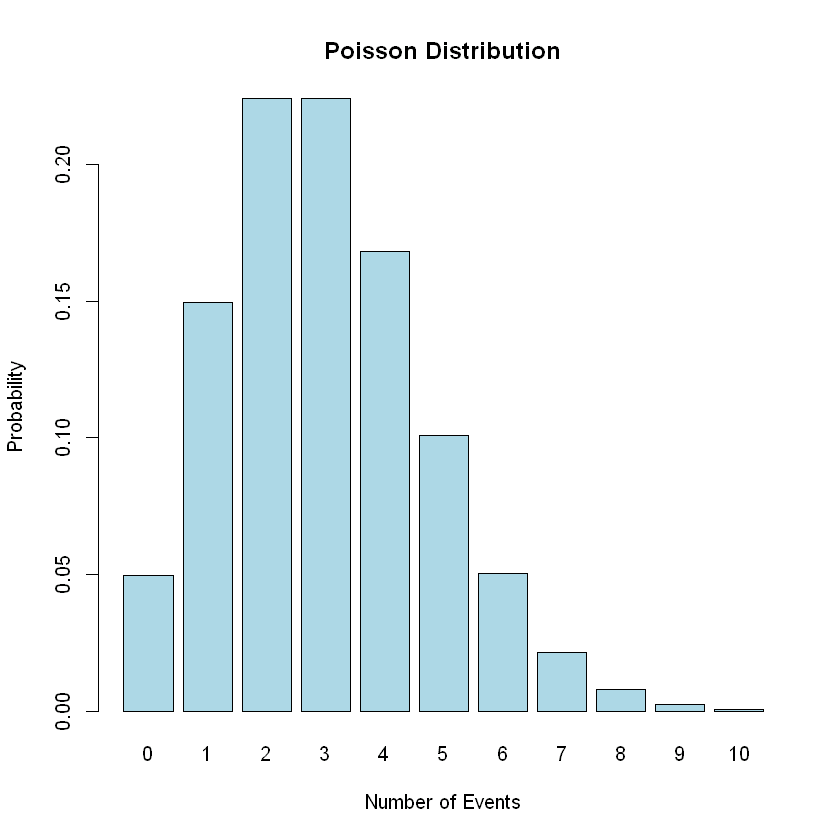

In [13]:
# Number of website visits per minute

x <- 0:10

y <- dpois(x, lambda = 3)

barplot(
  y,
  names.arg = x,
  main = "Poisson Distribution",
  xlab = "Number of Events",
  ylab = "Probability",
  col = "lightblue"
)

## Exponential Distribution

In [14]:
# In R, exponential densities are calculated with dexp().

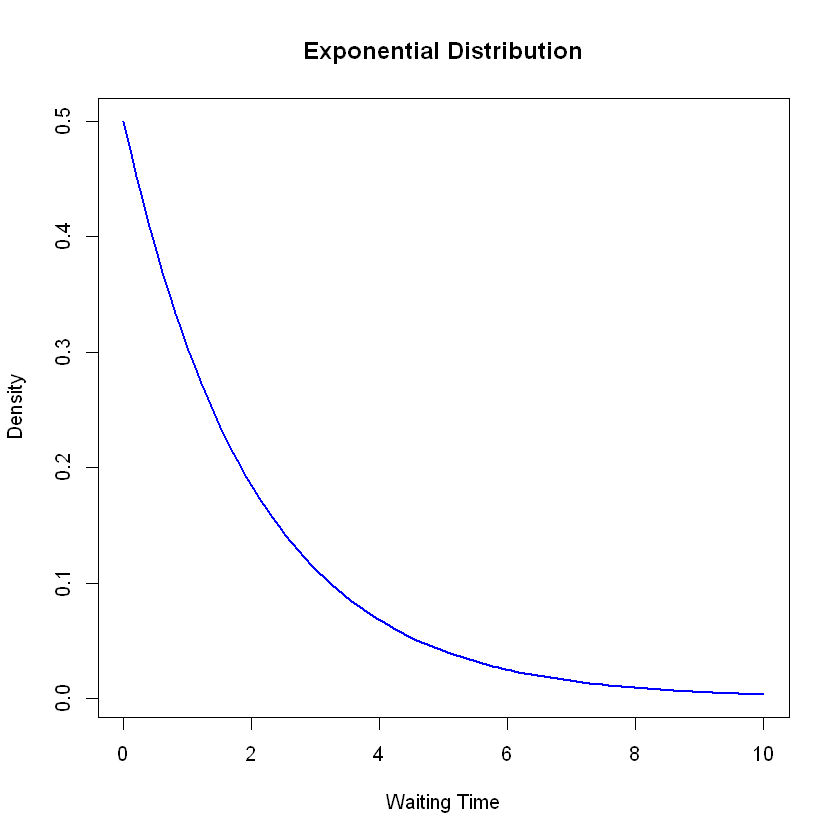

In [15]:
# Waiting time distribution

x <- seq(0, 10, length.out = 100)

y <- dexp(x, rate = 1 / 2)

plot(
  x, y,
  type = "l",
  main = "Exponential Distribution",
  xlab = "Waiting Time",
  ylab = "Density",
  col = "blue",
  lwd = 2
)

## Student's t-Distribution

In [16]:
# In R, random values from a t-distribution are generated with rt().

In [17]:
# Generate data from a t-distribution

# rt generates random values from the t-distribution

set.seed(42)

data_t <- rt(n = 1000, df = 5)

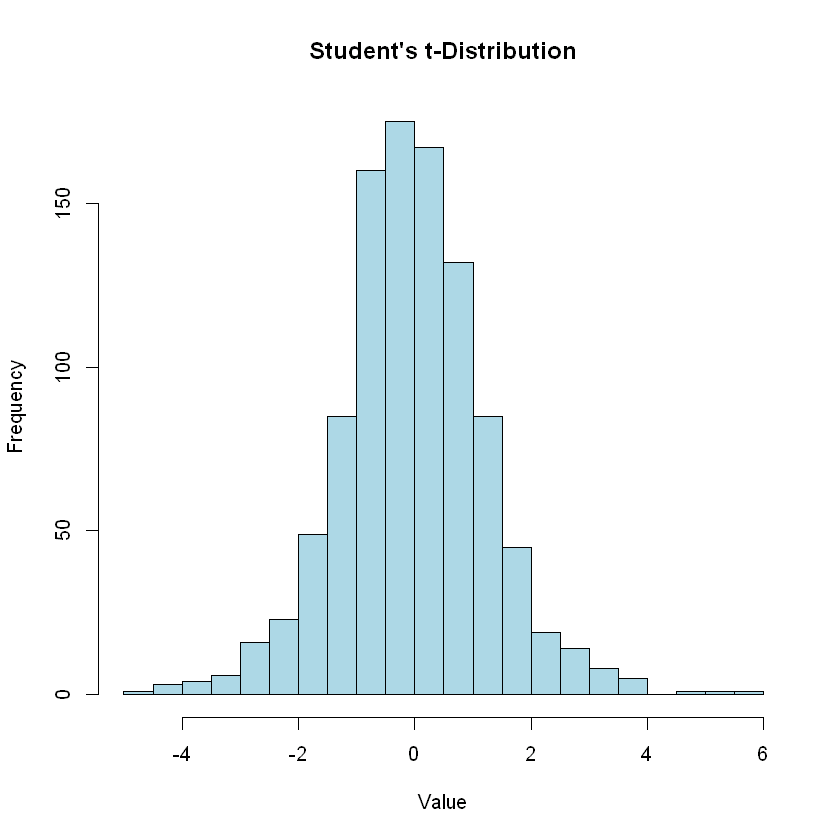

In [18]:
# Visualize the distribution

hist(
  data_t,
  breaks = 30,
  main = "Student's t-Distribution",
  xlab = "Value",
  ylab = "Frequency",
  col = "lightblue"
)

## Chi-Square Distribution

In [19]:
# In R, random values from a chi-square distribution are generated with rchisq().

In [20]:
# Generate chi-square data

set.seed(42)

data_chi <- rchisq(n = 1000, df = 4)

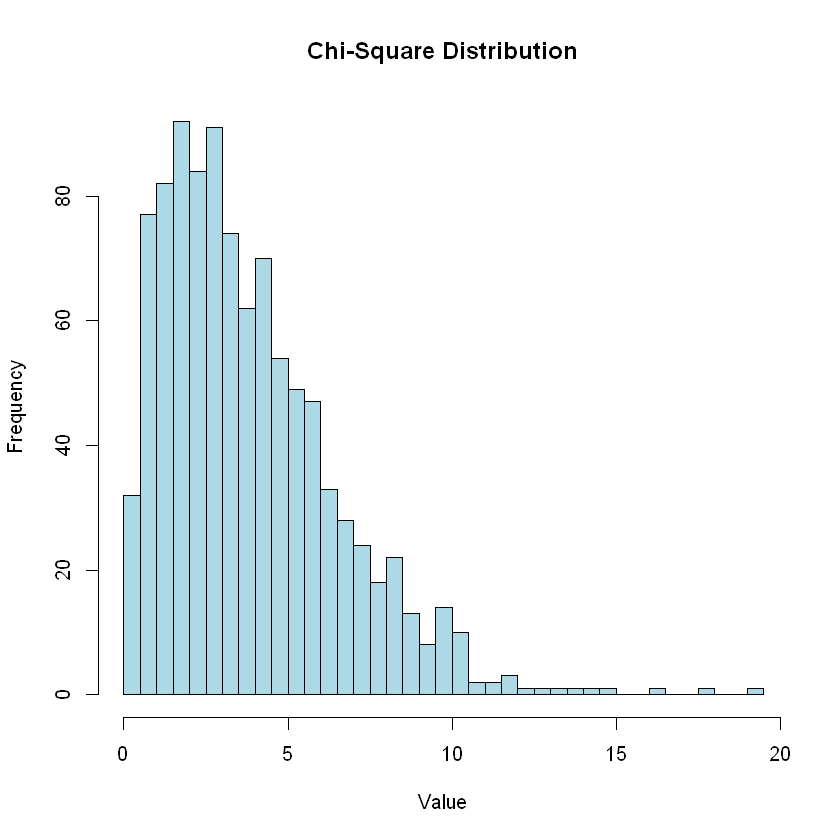

In [21]:
# Visualize the distribution

hist(
  data_chi,
  breaks = 30,
  main = "Chi-Square Distribution",
  xlab = "Value",
  ylab = "Frequency",
  col = "lightblue"
)

## F-Distribution

The F-distribution arises when comparing two sources of variability. It is commonly used in:

- Analysis of Variance (ANOVA)
- Comparing variances between groups
- Regression model evaluation

The shape of the F-distribution depends on two degrees of freedom parameters. It is always nonnegative and is typically right-skewed.

In [22]:
# In R, random values from an F-distribution are generated with rf().

In [23]:
# Generate F-distribution data

set.seed(42)

data_f <- rf(n = 1000, df1 = 5, df2 = 20)

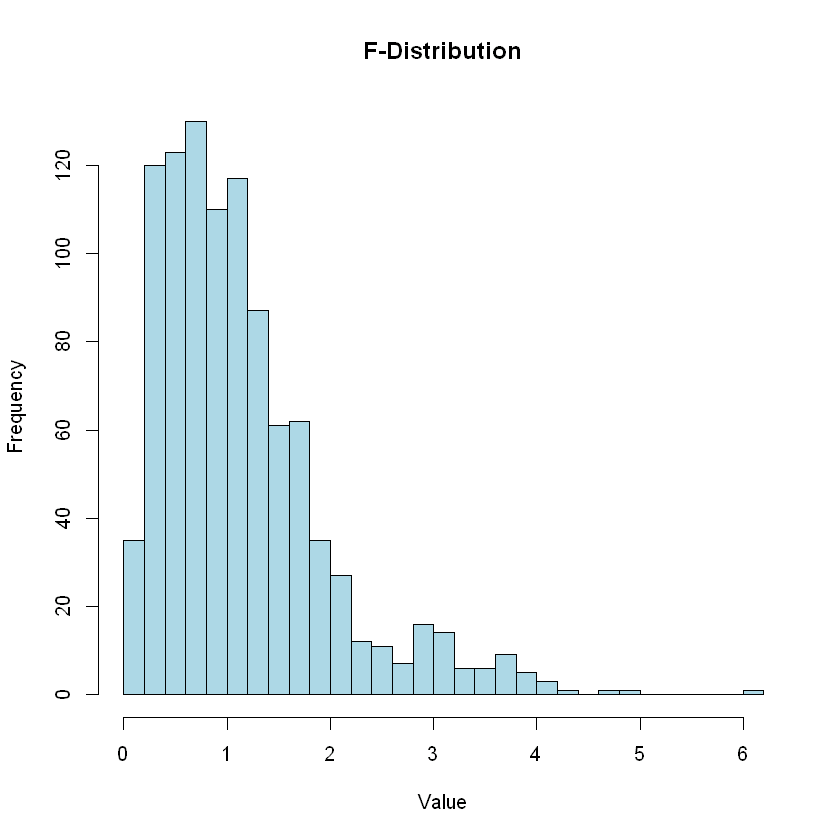

In [24]:
# Visualize the distribution

hist(
  data_f,
  breaks = 30,
  main = "F-Distribution",
  xlab = "Value",
  ylab = "Frequency",
  col = "lightblue"
)

# Appendix B: Monte Carlo Simulation

Monte Carlo simulation uses repeated random experiments to estimate probabilities and explore uncertainty.

Instead of solving a probability problem only with formulas, we allow the computer to simulate many possible outcomes and then study the results.


## A Coin-Flipping Example

Suppose a fair coin is flipped 20 times. We want to estimate the probability of obtaining at least 15 heads.

We already know this problem can be solved using the binomial distribution. Here, we use simulation instead.


In [25]:
# Monte Carlo simulation: 20 coin flips

set.seed(42)

num_simulations <- 10000
num_flips <- 20

# Simulate coin flips
# 1 represents heads, 0 represents tails
coin_flips <- matrix(
  sample(0:1, size = num_simulations * num_flips, replace = TRUE),
  nrow = num_simulations,
  ncol = num_flips
)

# Count heads in each simulation
heads_count <- rowSums(coin_flips)

# Estimate the probability of getting at least 15 heads
prob_at_least_15 <- mean(heads_count >= 15)

cat("Estimated probability of at least 15 heads:\n")
cat(round(prob_at_least_15, 4), "\n")

Estimated probability of at least 15 heads:
0.0205 


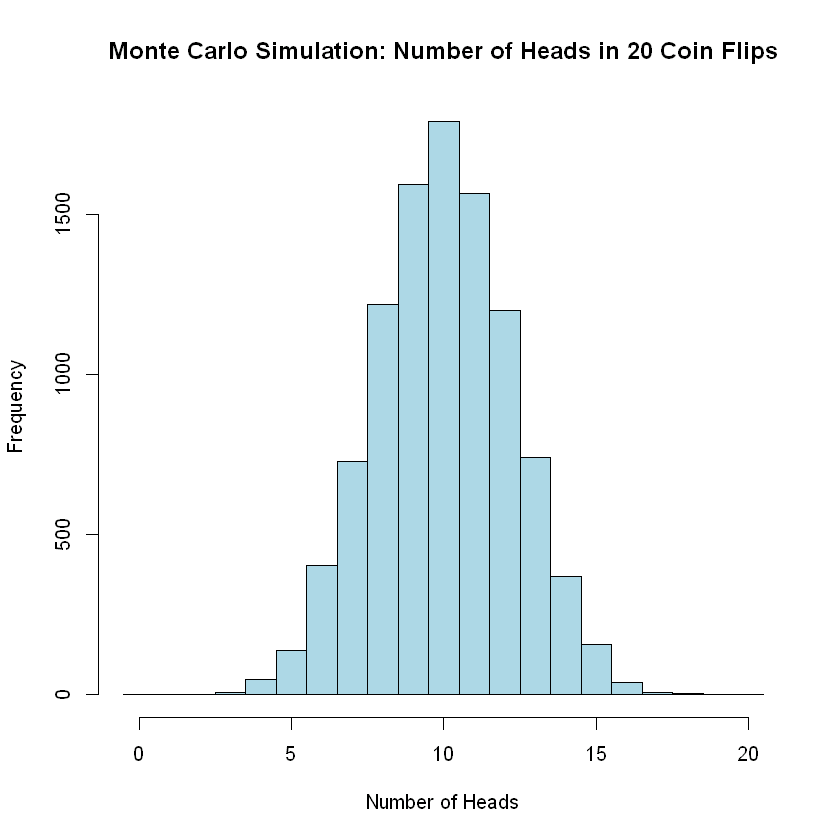

In [26]:
# Visualize the simulated number of heads

hist(
  heads_count,
  breaks = seq(-0.5, num_flips + 0.5, by = 1),
  main = "Monte Carlo Simulation: Number of Heads in 20 Coin Flips",
  xlab = "Number of Heads",
  ylab = "Frequency",
  col = "lightblue"
)

The simulated probability will not be exactly the same every time because the simulation itself is random.

However, as the number of simulations becomes large, the estimate usually becomes more stable.


In [27]:
# Compare different numbers of simulations

simulation_sizes <- c(100, 1000, 10000, 100000)

for (size in simulation_sizes) {
  flips <- matrix(
    sample(0:1, size = size * num_flips, replace = TRUE),
    nrow = size,
    ncol = num_flips
  )

  heads <- rowSums(flips)
  estimated_probability <- mean(heads >= 15)

  cat(
    sprintf(
      "Simulations: %6d | Estimated probability: %.4f\n",
      size,
      estimated_probability
    )
  )
}

Simulations:    100 | Estimated probability: 0.0300
Simulations:   1000 | Estimated probability: 0.0200
Simulations:  10000 | Estimated probability: 0.0224
Simulations: 100000 | Estimated probability: 0.0210


## Estimating Investment Risk

Monte Carlo simulation is also useful when we want to understand risk.

Suppose two investments have the same expected annual return, but different levels of variability:

- Investment A: mean return = 10%, standard deviation = 10%
- Investment B: mean return = 10%, standard deviation = 30%

We simulate many possible annual returns for each investment and compare the results.


In [28]:
# Monte Carlo simulation: investment returns

set.seed(42)

num_simulations <- 10000

investment_A <- rnorm(n = num_simulations, mean = 0.10, sd = 0.10)
investment_B <- rnorm(n = num_simulations, mean = 0.10, sd = 0.30)

prob_loss_A <- mean(investment_A < 0)
prob_loss_B <- mean(investment_B < 0)

prob_high_return_A <- mean(investment_A > 0.25)
prob_high_return_B <- mean(investment_B > 0.25)

cat("Probability of losing money:\n")
cat("Investment A:", round(prob_loss_A, 4), "\n")
cat("Investment B:", round(prob_loss_B, 4), "\n")

cat("\nProbability of earning more than 25%:\n")
cat("Investment A:", round(prob_high_return_A, 4), "\n")
cat("Investment B:", round(prob_high_return_B, 4), "\n")

Probability of losing money:
Investment A: 0.1648 
Investment B: 0.3665 

Probability of earning more than 25%:
Investment A: 0.0658 
Investment B: 0.3106 


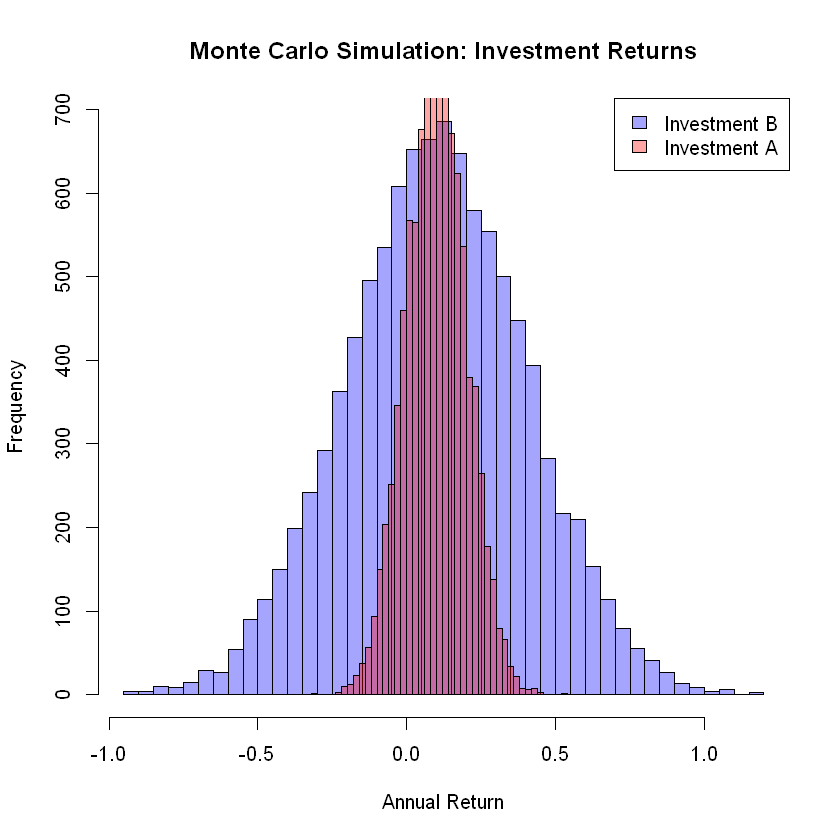

In [29]:
# Visualize the simulated investment returns

hist(
  investment_B,
  breaks = 40,
  col = rgb(0, 0, 1, 0.35),
  main = "Monte Carlo Simulation: Investment Returns",
  xlab = "Annual Return",
  ylab = "Frequency"
)

hist(
  investment_A,
  breaks = 40,
  col = rgb(1, 0, 0, 0.35),
  add = TRUE
)

legend(
  "topright",
  legend = c("Investment B", "Investment A"),
  fill = c(rgb(0, 0, 1, 0.35), rgb(1, 0, 0, 0.35))
)

Both investments have the same expected return, but the simulations show that they have very different risk profiles.

Investment B has a wider range of possible outcomes. It may produce very high returns in some simulations, but it also has a greater chance of producing losses.

This illustrates one of the main benefits of Monte Carlo simulation: it helps us understand not only what is expected, but also what is possible.


## Why Simulation Is Useful

Monte Carlo simulation is helpful because many real-world problems involve uncertainty and many possible outcomes.

Simulation allows analysts to explore questions such as:

- What might happen?
- How likely is each outcome?
- How much risk is involved?
- How sensitive are the results to randomness?

For this reason, Monte Carlo simulation is widely used in finance, engineering, operations research, project planning, and data science.


In [30]:
# End of Chapter 2 R notebook